##Network Analysis on Bitcoin OTC trust weighted signed network dataset

About the dataset: This is who-trusts-whom network of people who trade using Bitcoin on a platform called Bitcoin OTC. Since Bitcoin users are anonymous, there is a need to maintain a record of users' reputation to prevent transactions with fraudulent and risky users. Members of Bitcoin OTC rate other members in a scale of -10 (total distrust) to +10 (total trust) in steps of 1. This is the first explicit weighted signed directed network available for research.

##columns

source (Node): The user or entity giving the rating (trustor)

target (Node): The user or entity receiving the rating (trustee)

rating (Edge weight):The trust score or sentiment given by the source to the target (positive = trust, negative = distrust)

timestamp :The date and time when the rating was given




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [ ]:
df = pd.read_csv('/content/soc-sign-bitcoinotc.csv', names=["source", "target", "rating", "timestamp"])
df.head()

,source,target,rating,timestamp
0,6,2,4,1.289242e+09
1,6,5,2,1.289242e+09
2,1,15,1,1.289243e+09
3,4,3,7,1.289245e+09
4,13,16,8,1.289254e+09


In [ ]:
df.tail()

,source,target,rating,timestamp
35587,4499,1810,1,1.453612e+09
35588,2731,3901,5,1.453679e+09
35589,2731,4897,5,1.453679e+09
35590,13,1128,1,1.453680e+09
35591,1128,13,2,1.453684e+09


In [ ]:
#changing timestamp to datetime data
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

In [ ]:
df.head()

,source,target,rating,timestamp
0,6,2,4,2010-11-08 18:45:11.728359938
1,6,5,2,2010-11-08 18:45:41.533780098
2,1,15,1,2010-11-08 19:05:40.390490055
3,4,3,7,2010-11-08 19:41:17.369750023
4,13,16,8,2010-11-08 22:10:54.447459936


In [ ]:
df.tail()

,source,target,rating,timestamp
35587,4499,1810,1,2016-01-24 05:14:41.647289991
35588,2731,3901,5,2016-01-24 23:50:28.049489975
35589,2731,4897,5,2016-01-24 23:50:34.034019947
35590,13,1128,1,2016-01-24 23:53:52.985709906
35591,1128,13,2,2016-01-25 01:12:03.757280111


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35592 entries, 0 to 35591
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source     35592 non-null  int64         
 1   target     35592 non-null  int64         
 2   rating     35592 non-null  int64         
 3   timestamp  35592 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.1 MB


In [ ]:
#creating a network graph
G = nx.DiGraph()
for _, row in df.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["rating"])

print("\nGraph Created:")
# Basic network properties
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_clustering = nx.average_clustering(G.to_undirected(), weight='rating')

print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Density: {density}")
print(f"Average Clustering Coefficient: {avg_clustering}")



Graph Created:
Nodes: 5881
Edges: 35592
Density: 0.0010292571373048454
Average Clustering Coefficient: 0.17750449405289517


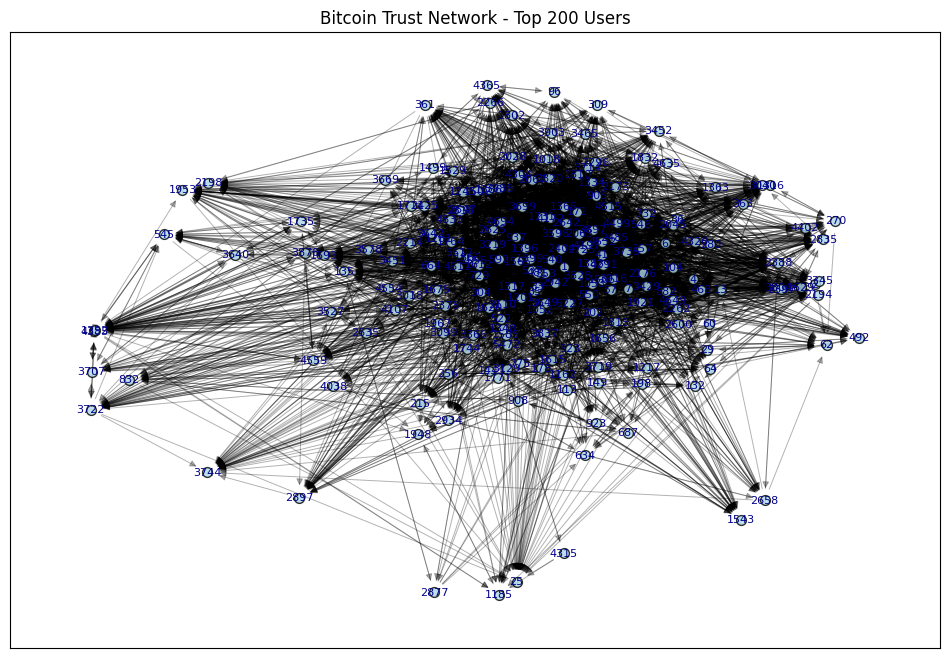

In [ ]:
# Select the top 200 most connected users based on degree
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:200]  # Change to 100 if needed
selected_users = [node for node, _ in top_nodes]
subG = G.subgraph(selected_users)

# Generate a force-directed layout for better spacing
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subG, seed=42, k=0.7)  # Higher k spreads nodes out more

# Draw nodes with a reasonable size
nx.draw_networkx_nodes(subG, pos, node_size=50, node_color='lightblue', edgecolors='black', alpha=0.8)

# Draw edges with reduced opacity to prevent clutter
nx.draw_networkx_edges(subG, pos, alpha=0.3, width=0.7)

# Display labels for the most connected users
nx.draw_networkx_labels(subG, pos, font_size=8, font_color='darkblue')

plt.title("Bitcoin Trust Network - Top 200 Users")
plt.show()



Top 20 Nodes by Degree Centrality:
User 35: 0.22074829931972786
User 2642: 0.1391156462585034
User 1810: 0.12159863945578231
User 2125: 0.09812925170068026
User 2028: 0.09727891156462584
User 905: 0.08979591836734693
User 4172: 0.08265306122448979
User 7: 0.07619047619047618
User 1: 0.075
User 4197: 0.06887755102040816
User 13: 0.06819727891156462
User 1018: 0.06496598639455782
User 2296: 0.0586734693877551
User 1953: 0.05680272108843537
User 2388: 0.05663265306122449
User 4291: 0.05612244897959183
User 1334: 0.055782312925170066
User 546: 0.05289115646258503
User 1386: 0.05204081632653061
User 3988: 0.05187074829931972


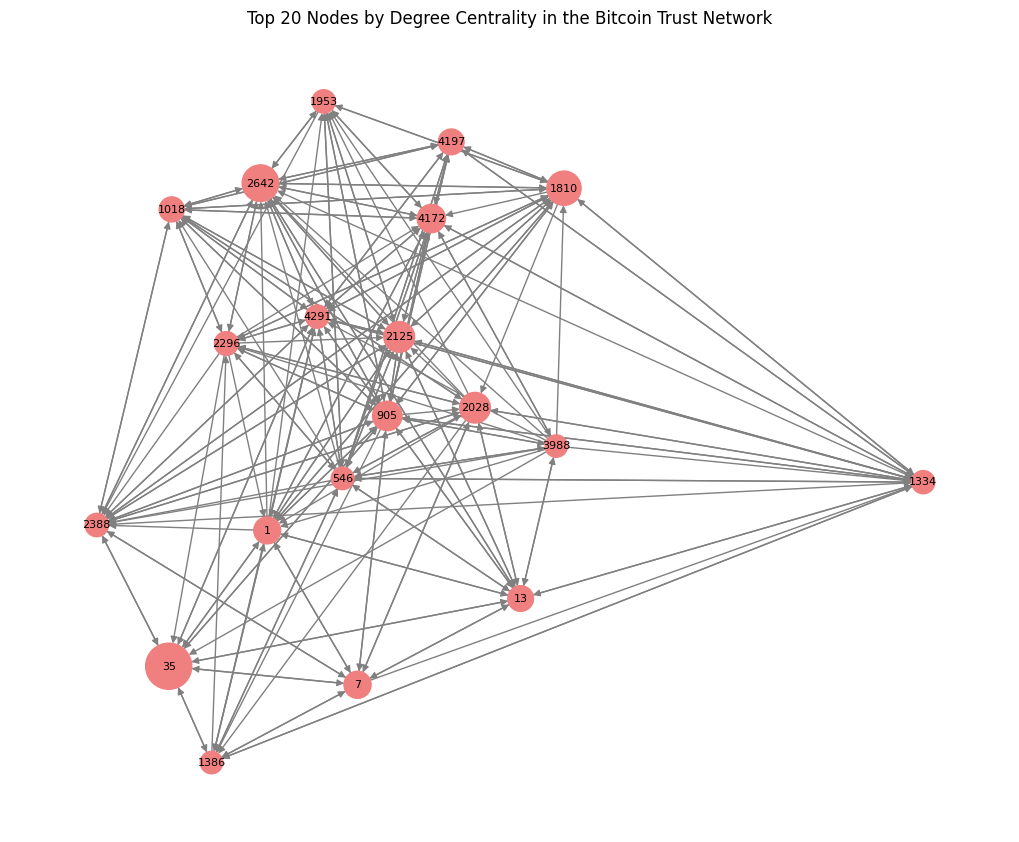

In [ ]:
#Who are the most influential users in the trust network?
# Compute degree centrality
degree_centrality = nx.degree_centrality(G)

# Get top 20 nodes by degree centrality
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:20]
top_users = {user for user, _ in top_degree}

# Print top 20 nodes
print("\nTop 20 Nodes by Degree Centrality:")
for user, score in top_degree:
    print(f"User {user}: {score}")

# Create a subgraph with only the top 20 users
subG = G.subgraph(top_users)

# Draw the network graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subG, seed=42)  # Layout for visualization
node_size = [degree_centrality[node] * 5000 for node in subG.nodes()]  # Scale node size by degree centrality

nx.draw(subG, pos, with_labels=True, node_color='lightcoral', node_size=node_size, edge_color='gray', font_size=8)
plt.title("Top 20 Nodes by Degree Centrality in the Bitcoin Trust Network")
plt.show()


Top 20 Influential Users (PageRank):
User 35: 0.015107372805455366
User 2642: 0.010816035128244547
User 1810: 0.0069758388155288205
User 2028: 0.006775820078635073
User 7: 0.005912435786337965
User 905: 0.00537234003814549
User 1953: 0.005159445975183549
User 1: 0.005029048679852529
User 4172: 0.004785609355691647
User 4197: 0.004672174052144944
User 13: 0.004285772484391748
User 1018: 0.004083886139251873
User 2125: 0.0038798722323221675
User 2296: 0.003360715863324579
User 202: 0.003342619522839635
User 3735: 0.003240906778075278
User 546: 0.003166467567669499
User 4291: 0.00311426746441035
User 1334: 0.0031130960277229052
User 1899: 0.0029726798732604316


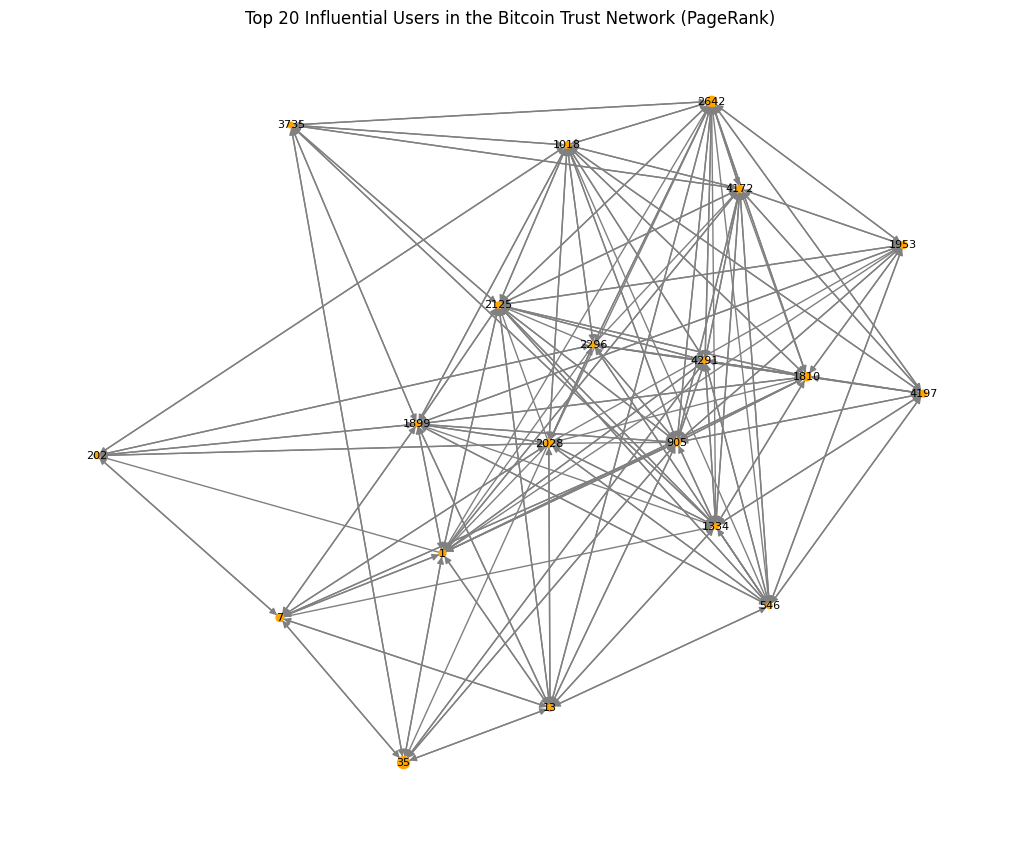

In [ ]:
# Identifying Influential Users (PageRank)
# Compute PageRank with weight
pagerank = nx.pagerank(G, weight='rating')

# Get top 20 influential users
top_influential = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:20]
top_users = {user for user, _ in top_influential}

# Print top 20 influential users
print("\nTop 20 Influential Users (PageRank):")
for user, score in top_influential:
    print(f"User {user}: {score}")

# Create a subgraph with only the top influential users and their connections
subG = G.subgraph(top_users)

# Draw the network graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subG, seed=42)  # Positioning for better visualization
node_size = [pagerank[node] * 5000 for node in subG.nodes()]  # Scale node size by PageRank score

nx.draw(subG, pos, with_labels=True, node_color='orange', node_size=node_size, edge_color='gray', font_size=8)
plt.title("Top 20 Influential Users in the Bitcoin Trust Network (PageRank)")
plt.show()


Top 20 Users Acting as Intermediaries:
User 35: 0.14211022254570446
User 2642: 0.06220168253637525
User 1810: 0.049533487572168064
User 905: 0.048142532048893405
User 1: 0.044997192103169
User 4172: 0.04189794211378277
User 2125: 0.04163270169885217
User 7: 0.03982175327702963
User 2028: 0.0387828896318293
User 1953: 0.032305227236014686
User 13: 0.03223521837548451
User 2388: 0.025361292868165086
User 1018: 0.022438773575925337
User 2067: 0.021577510719149668
User 546: 0.020631656982740786
User 1334: 0.019519413199267914
User 3988: 0.01897457266935395
User 1352: 0.018696586115981587
User 2296: 0.01837800256748982
User 4197: 0.018155159172410403


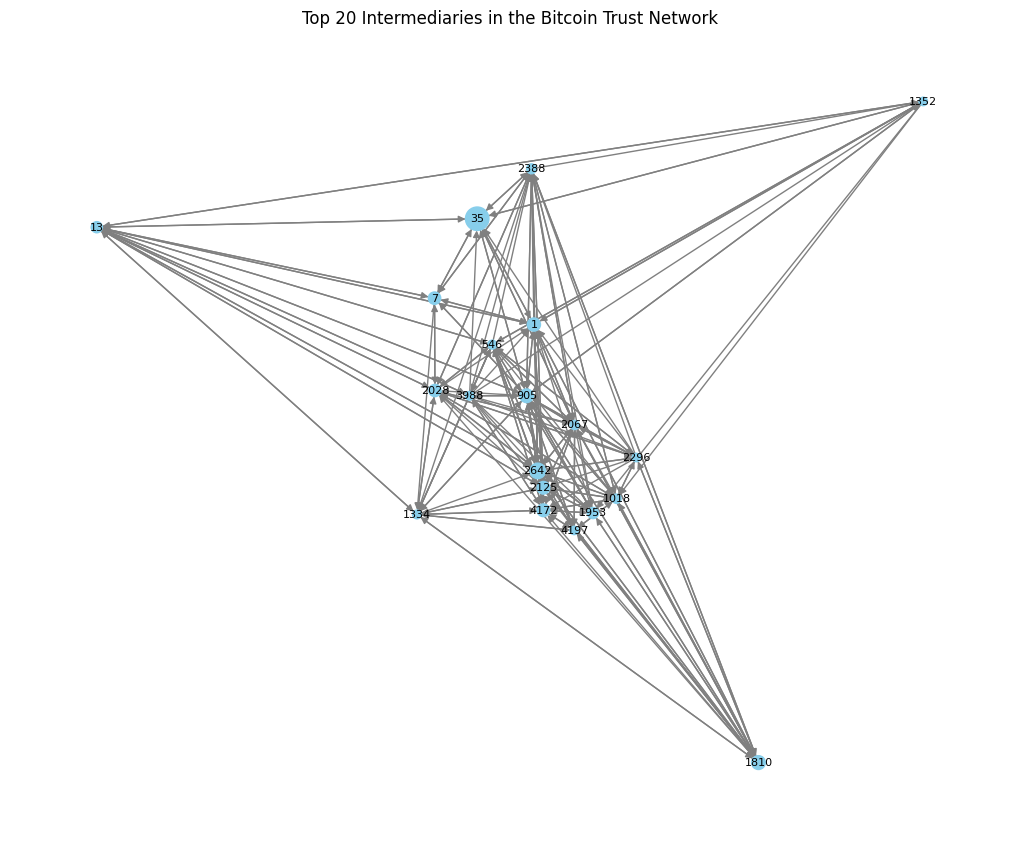

In [ ]:
# Who are the key intermediaries bridging trust between groups?
betweenness = nx.betweenness_centrality(G, weight='rating')
top_intermediaries = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:20]
print("\nTop 20 Users Acting as Intermediaries:")
for user, score in top_intermediaries:
    print(f"User {user}: {score}")



# Get top 20 intermediaries
top_intermediaries = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:20]
top_users = {user for user, _ in top_intermediaries}

# Create a subgraph with only the top intermediaries and their connections
subG = G.subgraph(top_users)

# Draw the network graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subG, seed=42)  # Positioning for better visualization
node_size = [betweenness[node] * 2000 for node in subG.nodes()]  # Scale node size by centrality

nx.draw(subG, pos, with_labels=True, node_color='skyblue', node_size=node_size, edge_color='gray', font_size=8)
plt.title("Top 20 Intermediaries in the Bitcoin Trust Network")
plt.show()

In [ ]:
# Are there users who receive high trust but give low trust?
in_degree = dict(G.in_degree(weight='rating'))
out_degree = dict(G.out_degree(weight='rating'))
disparity_users = [(u, in_degree[u], out_degree.get(u, 0)) for u in in_degree if in_degree[u] > 2 * out_degree.get(u, 0)]
top_disparity = sorted(disparity_users, key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Users Receiving High Trust but Giving Low Trust:")
for user, received, given in top_disparity:
    print(f"User {user}: Received {received}, Given {given}")


Top 10 Users Receiving High Trust but Giving Low Trust:
User 25: Received 113, Given 0
User 2198: Received 85, Given 0
User 3744: Received 81, Given 32
User 545: Received 79, Given 23
User 62: Received 52, Given 14
User 2017: Received 45, Given 9
User 2498: Received 45, Given 0
User 4683: Received 33, Given 11
User 4707: Received 33, Given 3
User 230: Received 32, Given 5


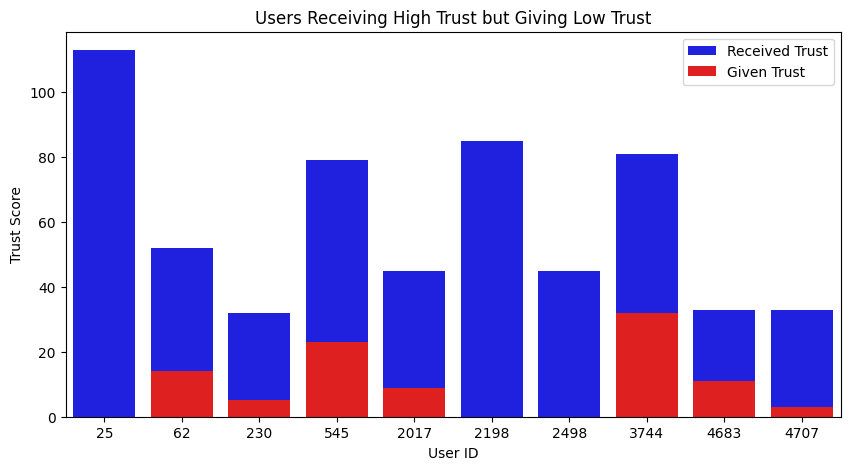

In [ ]:
# Visualization for High Trust but Low Trust-Giving Users
if top_disparity:
    disparity_df = pd.DataFrame(top_disparity, columns=["User", "Received Trust", "Given Trust"])
    plt.figure(figsize=(10, 5))
    sns.barplot(x="User", y="Received Trust", data=disparity_df, color='blue', label='Received Trust')
    sns.barplot(x="User", y="Given Trust", data=disparity_df, color='red', label='Given Trust')
    plt.xlabel("User ID")
    plt.ylabel("Trust Score")
    plt.title("Users Receiving High Trust but Giving Low Trust")
    plt.legend()
    plt.show()

In [ ]:
#How is trust distributed among users in the Bitcoin OTC network?
from community import community_louvain
df_positive = df[df['rating'] > 0]  # Use only positive trust for community detection

# Create undirected graph (communities) with summed positive ratings
G_undirected = nx.from_pandas_edgelist(
    df_positive,
    'source',
    'target',
    edge_attr='rating',
    create_using=nx.Graph()
)

# Simplify edge weights by summing multiple ratings between the same users
G_undirected = nx.Graph()
for _, row in df_positive.iterrows():
    if G_undirected.has_edge(row['source'], row['target']):
        G_undirected[row['source']][row['target']]['rating'] += row['rating']
    else:
        G_undirected.add_edge(row['source'], row['target'], rating=row['rating'])

# --------------------------------------------
# 9. Detect Communities (Fixed)
# --------------------------------------------
partition = community_louvain.best_partition(G_undirected, resolution=0.8)
community_counts = pd.Series(partition).value_counts().head(5)
print("\nTop 5 Largest Communities:")
print(community_counts)


Top 5 Largest Communities:
2     1617
0     1370
3      934
26     581
4      532
Name: count, dtype: int64


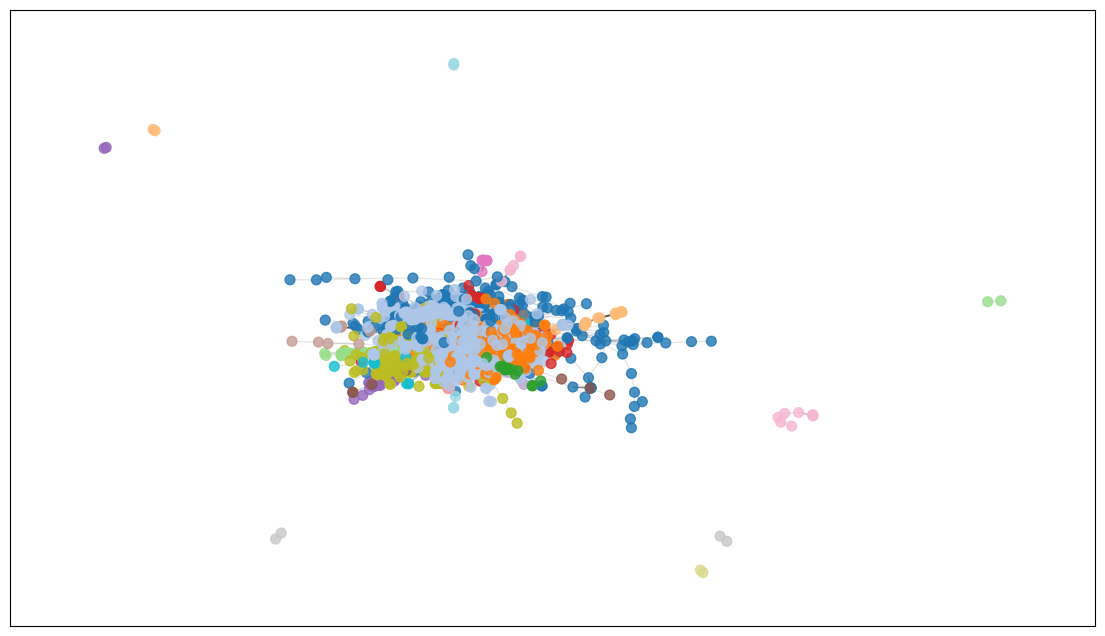

In [ ]:
plt.figure(figsize=(14, 8))
pos = nx.spring_layout(G_undirected, seed=42)
node_colors = [partition[node] for node in G_undirected.nodes()]
nx.draw_networkx_nodes(G_undirected, pos, node_size=50, node_color=node_colors, cmap=plt.cm.tab20, alpha=0.8)
nx.draw_networkx_edges(G_undirected, pos, alpha=0.1)

<ipython-input-17-98bd95322a2a>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trust_over_time = df['rating'].resample('M').mean()


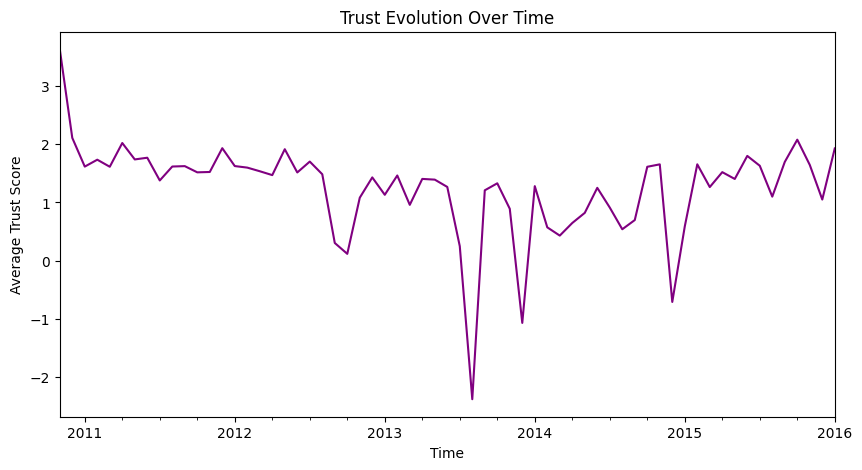

In [ ]:
# How does trust change over time in the network?
# Trust Evolution Over Time
df.set_index('timestamp', inplace=True)
trust_over_time = df['rating'].resample('M').mean()
plt.figure(figsize=(10, 5))
trust_over_time.plot(color='purple')
plt.xlabel("Time")
plt.ylabel("Average Trust Score")
plt.title("Trust Evolution Over Time")
plt.show()


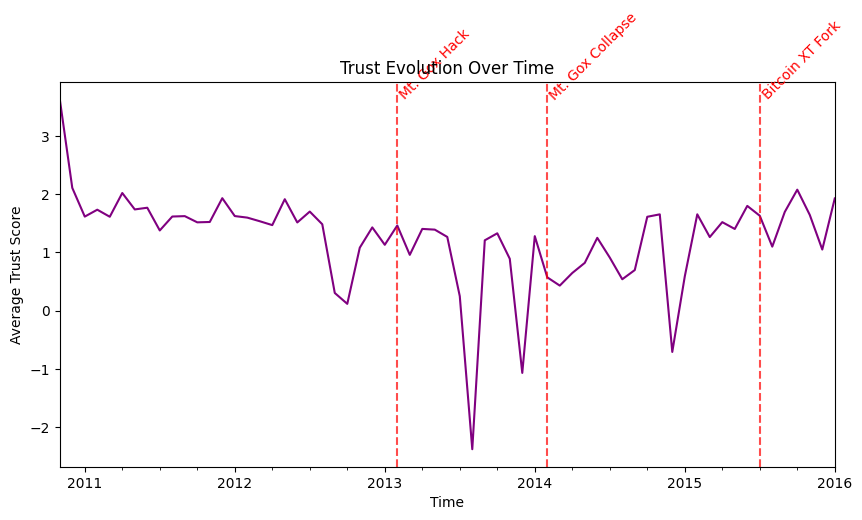

In [ ]:
#Are there significant events that correspond to major shifts in trust?
events = {
    "2013-02": "Mt. Gox Hack",
    "2014-02": "Mt. Gox Collapse",
    "2015-07": "Bitcoin XT Fork"
}

plt.figure(figsize=(10, 5))
trust_over_time.plot(color='purple')
plt.xlabel("Time")
plt.ylabel("Average Trust Score")
plt.title("Trust Evolution Over Time")

# Mark events
for date, event in events.items():
    plt.axvline(pd.to_datetime(date), color='red', linestyle="--", alpha=0.7)
    plt.text(pd.to_datetime(date), trust_over_time.max(), event, rotation=45, color='red')

plt.show()


In [ ]:
#How do users regain trust after a decline?
initial_trust = df[df.index < "2013-01-01"].groupby("source")["rating"].mean()
final_trust = df[df.index > "2015-01-01"].groupby("source")["rating"].mean()
trust_recovery = pd.DataFrame({"Initial": initial_trust, "Final": final_trust}).dropna()
trust_recovery["Change"] = trust_recovery["Final"] - trust_recovery["Initial"]

print("\nTop 10 Users Who Gained the Most Trust Over Time:")
print(trust_recovery.sort_values("Change", ascending=False).head(10))



Top 10 Users Who Gained the Most Trust Over Time:
         Initial     Final    Change
source                              
481    -5.250000  2.666667  7.916667
1819    2.300000  9.000000  6.700000
2067   -3.458716  2.142857  5.601573
2       3.047619  8.000000  4.952381
2073    1.333333  5.500000  4.166667
1810   -1.557895  1.625000  3.182895
2552   -0.142857  2.666667  2.809524
1639   -0.142857  2.600000  2.742857
1565    1.648649  4.375000  2.726351
2731    1.000000  3.666667  2.666667


<ipython-input-24-b7fd74eeeace>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trust_volume = df.resample('M').size()
<ipython-input-24-b7fd74eeeace>:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trust_over_time = df['rating'].resample('M').mean()


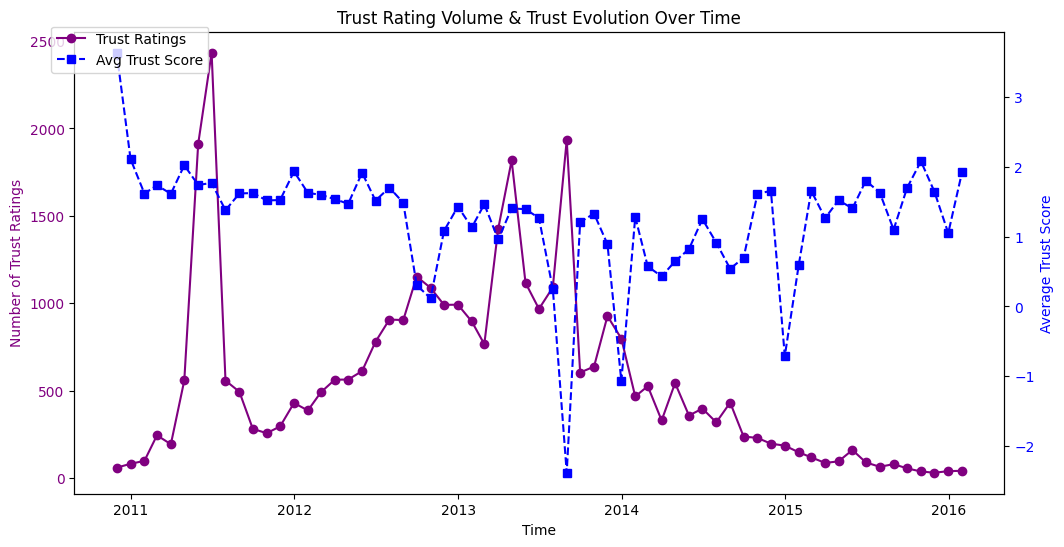

In [ ]:
#Does More Trust Ratings Mean Higher Trust?

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Calculate trust rating volume (count of ratings per month)
trust_volume = df.resample('M').size()

# Calculate average trust score per month
trust_over_time = df['rating'].resample('M').mean()

# Create a dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot trust rating volume
color = 'purple'
ax1.set_xlabel("Time")
ax1.set_ylabel("Number of Trust Ratings", color=color)
ax1.plot(trust_volume.index, trust_volume.values, marker='o', color=color, label="Trust Ratings")
ax1.tick_params(axis='y', labelcolor=color)

# Create second y-axis
ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel("Average Trust Score", color=color)
ax2.plot(trust_over_time.index, trust_over_time.values, marker='s', linestyle='--', color=color, label="Avg Trust Score")
ax2.tick_params(axis='y', labelcolor=color)

# Title and legend
plt.title("Trust Rating Volume & Trust Evolution Over Time")
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.show()


<ipython-input-26-06054913f6ee>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trust_volume = df.resample('M').size()
<ipython-input-26-06054913f6ee>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trust_over_time = df['rating'].resample('M').mean()


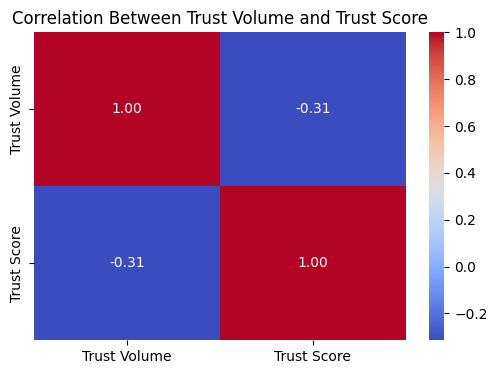

Pearson Correlation: -0.31
Spearman Correlation: -0.34


In [ ]:
# Resample to monthly data
trust_volume = df.resample('M').size()
trust_over_time = df['rating'].resample('M').mean()

# Compute correlation
correlation_pearson = trust_volume.corr(trust_over_time, method='pearson')
correlation_spearman = trust_volume.corr(trust_over_time, method='spearman')

# Plot correlation heatmap
corr_df = pd.DataFrame({'Trust Volume': trust_volume, 'Trust Score': trust_over_time})
corr_matrix = corr_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Trust Volume and Trust Score")
plt.show()

print(f"Pearson Correlation: {correlation_pearson:.2f}")
print(f"Spearman Correlation: {correlation_spearman:.2f}")